# HBR SHASH: MCMC vs VI

| Method | What it does |
|---|---|
| `laplace` | Gaussian centred on the posterior mode, covariance from the Hessian there (needs `pymc-extras`). |

## Imports

In [1]:
import logging
import time
import warnings

import pandas as pd

import pcntoolkit.util.output
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    SHASHbLikelihood,
    load_fcon1000,
    make_prior,
)

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pymc").propagate = False
warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(False)

## Load data

Data and model specification is the same as the `HBR_SHASH` notebook

In [2]:
norm_data: NormData = load_fcon1000()
# Six response variables with different shapes: a skewed count-like measure,
# ventricles, subcortical volumes, a global volume and cortical thickness.
features_to_model = [
    "WM-hypointensities",
    "Right-Lateral-Ventricle",
    "Right-Amygdala",
    "Left-Hippocampus",
    "CortexVol",
    "lh_G_front_middle_thickness",
]
norm_data = norm_data.sel({"response_vars": features_to_model})
train, test = norm_data.train_test_split()
print(f"train observations: {train.X.shape[0]}")
print(f"response variables: {len(features_to_model)}")

train observations: 862
response variables: 6


## Model specification


In [3]:
def make_shashb_likelihood() -> SHASHbLikelihood:
    """Build the SHASHb likelihood used in 04_HBR_SHASH.ipynb."""
    mu = make_prior(
        linear=True,
        slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
        intercept=make_prior(
            random=True,
            mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
            sigma=make_prior(
                dist_name="Normal",
                dist_params=(0.0, 1.0),
                mapping="softplus",
                mapping_params=(0.0, 3.0),
            ),
        ),
        basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    )
    sigma = make_prior(
        linear=True,
        slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
        intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
        basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
        mapping="softplus",
        mapping_params=(0.0, 3.0),
    )
    epsilon = make_prior(dist_name="Normal", dist_params=(0.0, 1.0))
    delta = make_prior(
        dist_name="Normal",
        dist_params=(1.0, 1.0),
        mapping="softplus",
        mapping_params=(0.0, 3.0, 0.6),
    )
    return SHASHbLikelihood(mu, sigma, epsilon, delta)


def build_model(inference_method: str) -> NormativeModel:
    """Wrap the SHASHb HBR in a NormativeModel using the given inference method."""
    reg = HBR(
        name="template",
        cores=16,
        progressbar=False,
        draws=1500,
        tune=500,
        chains=4,
        nuts_sampler="nutpie",
        likelihood=make_shashb_likelihood(),
        # The new switch: "mcmc", "advi", "pathfinder", "dadvi" or "laplace".
        inference_method=inference_method,
        vi_iterations=30000,
        vi_draws=1000,
    )
    return NormativeModel(
        template_regression_model=reg,
        savemodel=False,
        evaluate_model=False,
        saveresults=False,
        saveplots=False,
        save_dir=f"resources/hbr_bench/{inference_method}",
        inscaler="standardize",
        outscaler="standardize",
    )

## Run the benchmark

Fit one model with each inference method. We also calculate how long each fit takes

In [4]:
timings: dict[str, float] = {}
fits: dict[str, NormativeModel] = {}   # keep every fit for the accuracy checks later

METHODS = ["mcmc",  "pathfinder", "laplace"]

for method in METHODS:
    print(f"=== {method} ===")
    try:
        m = build_model(method)
        t = time.time()
        m.fit(train)
        timings[method] = time.time() - t
        fits[method] = m
        print(f"  {method}: {timings[method]:.1f}s\n")
    except ImportError as e:
        print(f"  {method} SKIPPED: {e}\n")
    except Exception as e:
        print(f"  {method} FAILED: {type(e).__name__}: {e}\n")

=== mcmc ===


c:\Users\kontsi\AppData\Local\anaconda3\envs\ptk-vi\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


  mcmc: 542.6s

=== pathfinder ===


Pathfinder Results                            
                                              
  No. model parameters     45                 
                                              
  Configuration:                              
  num_draws_per_path       1000               
  history size (maxcor)    12                 
  max iterations           1000               
  ftol                     1.00e-05           
  gtol                     1.00e-08           
  max line search          1000               
  jitter                   2.0                
  epsilon                  1.00e-12           
  ELBO draws               10                 
                                              
  LBFGS Status:                               
  CONVERGED                4                  
  L-BFGS iterations        mean 201 ± std 8   
                                              
  Path Status:                                
  SUCCESS                  4                  
  ELBO argmax              mean 106 ± std 10  
                                              
  Importance Sampling:                        
  Method                   psis               
  Pareto k                 1.87               
                                              
  Timing (seconds):                           
  Compile                  10.88              
  Compute                  26.28              
  Total                    37.16

Pathfinder Results                            
                                              
  No. model parameters     45                 
                                              
  Configuration:                              
  num_draws_per_path       1000               
  history size (maxcor)    12                 
  max iterations           1000               
  ftol                     1.00e-05           
  gtol                     1.00e-08           
  max line search          1000               
  jitter                   2.0                
  epsilon                  1.00e-12           
  ELBO draws               10                 
                                              
  LBFGS Status:                               
  CONVERGED                4                  
  L-BFGS iterations        mean 134 ± std 18  
                                              
  Path Status:                                
  SUCCESS                  4                  
  ELBO argmax              mean 78 ± std 8    
                                              
  Importance Sampling:                        
  Method                   psis               
  Pareto k                 1.85               
                                              
  Timing (seconds):                           
  Compile                  9.90               
  Compute                  25.26              
  Total                    35.16

Pathfinder Results                           
                                             
  No. model parameters     45                
                                             
  Configuration:                             
  num_draws_per_path       1000              
  history size (maxcor)    12                
  max iterations           1000              
  ftol                     1.00e-05          
  gtol                     1.00e-08          
  max line search          1000              
  jitter                   2.0               
  epsilon                  1.00e-12          
  ELBO draws               10                
                                             
  LBFGS Status:                              
  CONVERGED                4                 
  L-BFGS iterations        mean 100 ± std 9  
                                             
  Path Status:                               
  SUCCESS                  4                 
  ELBO argmax              mean 82 ± std 6   
                                             
  Importance Sampling:                       
  Method                   psis              
  Pareto k                 2.10              
                                             
  Timing (seconds):                          
  Compile                  10.01             
  Compute                  25.62             
  Total                    35.62

Pathfinder Results                           
                                             
  No. model parameters     45                
                                             
  Configuration:                             
  num_draws_per_path       1000              
  history size (maxcor)    12                
  max iterations           1000              
  ftol                     1.00e-05          
  gtol                     1.00e-08          
  max line search          1000              
  jitter                   2.0               
  epsilon                  1.00e-12          
  ELBO draws               10                
                                             
  LBFGS Status:                              
  CONVERGED                4                 
  L-BFGS iterations        mean 106 ± std 6  
                                             
  Path Status:                               
  SUCCESS                  4                 
  ELBO argmax              mean 65 ± std 14  
                                             
  Importance Sampling:                       
  Method                   psis              
  Pareto k                 1.68              
                                             
  Timing (seconds):                          
  Compile                  8.64              
  Compute                  26.81             
  Total                    35.45

Pathfinder Results                           
                                             
  No. model parameters     45                
                                             
  Configuration:                             
  num_draws_per_path       1000              
  history size (maxcor)    12                
  max iterations           1000              
  ftol                     1.00e-05          
  gtol                     1.00e-08          
  max line search          1000              
  jitter                   2.0               
  epsilon                  1.00e-12          
  ELBO draws               10                
                                             
  LBFGS Status:                              
  CONVERGED                4                 
  L-BFGS iterations        mean 94 ± std 14  
                                             
  Path Status:                               
  SUCCESS                  4                 
  ELBO argmax              mean 68 ± std 13  
                                             
  Importance Sampling:                       
  Method                   psis              
  Pareto k                 2.13              
                                             
  Timing (seconds):                          
  Compile                  10.04             
  Compute                  24.94             
  Total                    34.98

Pathfinder Results                          
                                            
  No. model parameters     45               
                                            
  Configuration:                            
  num_draws_per_path       1000             
  history size (maxcor)    12               
  max iterations           1000             
  ftol                     1.00e-05         
  gtol                     1.00e-08         
  max line search          1000             
  jitter                   2.0              
  epsilon                  1.00e-12         
  ELBO draws               10               
                                            
  LBFGS Status:                             
  CONVERGED                4                
  L-BFGS iterations        mean 94 ± std 9  
                                            
  Path Status:                              
  SUCCESS                  4                
  ELBO argmax              mean 82 ± std 4  
                                            
  Importance Sampling:                      
  Method                   psis             
  Pareto k                 1.46             
                                            
  Timing (seconds):                         
  Compile                  10.31            
  Compute                  25.00            
  Total                    35.31

  pathfinder: 289.9s

=== laplace ===
  laplace: 94.3s



---

# Timing results

Conclusion: Pathfinder and ADVI have similar timings and are **~3 times faster** than MCMC for a sample of ~1000 subject with one response variable. 

We should investigate if this speedup holds for more subjects, more response variables and for HBR with normal likelihood 

In [5]:
ref = timings.get("mcmc")
rows = []
for k, v in sorted(timings.items(), key=lambda kv: kv[1]):
    rows.append({
        "method": k,
        "fit time (s)": round(v, 1),
        "speedup vs mcmc": f"{ref / v:.1f}x" if ref else "n/a",
    })
pd.DataFrame(rows)

,method,fit time (s),speedup vs mcmc
0,laplace,94.3,5.8x
1,pathfinder,289.9,1.9x
2,mcmc,542.6,1.0x


---

# Accuracy results

We check, in order of what actually reaches a paper:

1. **Z-scores** on held-out test data
2. **Centiles plots**
3. **Posterior width** - the diagnostic that explains errors in 1 and 2

For ADVI which is a mean-field VI we expect that it will get the *means* right but will underestimate the posterior **width**: narrow posteriors inflate z-scores and manufacture false outliers.

## Recover the fitted models

In [6]:
try:
    fits
except NameError:
    fits = {}

# `model` may hold the last fit from an older run of the fit cell.
if "model" in dir() and not fits:
    last = getattr(model.template_regression_model, "inference_method", None)
    if last:
        fits[last] = model
        print(f"recovered '{last}' from the previous run")

for method in METHODS:
    if method in fits:
        print(f"{method}: already fitted, reusing")
        continue
    print(f"{method}: refitting ...")
    try:
        m = build_model(method)
        t = time.time()
        m.fit(train)
        fits[method] = m
        timings[method] = time.time() - t
        print(f"  done in {timings[method]:.1f}s")
    except Exception as e:
        print(f"  FAILED: {type(e).__name__}: {e}")

print("\navailable:", sorted(fits))

mcmc: already fitted, reusing
pathfinder: already fitted, reusing
laplace: already fitted, reusing

available: ['laplace', 'mcmc', 'pathfinder']


## 1. Z-scores vs MCMC

### Metrics

`corr` should be as close to 1 as possible and `max|dz|` small (this shows if a specific subject's z score diverged a lot from the reference MCMC). 

In [7]:
import numpy as np

CENTILES = [0.05, 0.25, 0.5, 0.75, 0.95]
RESPONSE_VARS = [str(r) for r in features_to_model]

# Z-scores keyed by (method, response_var): predict() writes one column per
# response variable, so they must be kept apart rather than flattened together.
zs: dict[tuple[str, str], np.ndarray] = {}
for method, m in fits.items():
    td = test.copy()
    m.predict(td)
    for rv in RESPONSE_VARS:
        zs[(method, rv)] = np.asarray(td["Z"].sel(response_vars=rv).values).ravel()

others = [k for k in fits if k != "mcmc"]

rows = []
for rv in RESPONSE_VARS:
    zref_rv = zs[("mcmc", rv)]
    for method in others:
        z = zs[(method, rv)]
        d = np.abs(z - zref_rv)
        rows.append({
            "response_var": rv,
            "method": method,
            "corr": round(float(np.corrcoef(z, zref_rv)[0, 1]), 4),
            "max |dz|": round(float(d.max()), 4),
            "mean |dz|": round(float(d.mean()), 4),
            "sd ratio": round(float(z.std() / zref_rv.std()), 4),
        })

z_df = pd.DataFrame(rows)
print("mean over response variables:")
print(z_df.groupby("method")[["corr", "max |dz|", "mean |dz|", "sd ratio"]].mean().round(4))
z_df

mean over response variables:
              corr  max |dz|  mean |dz|  sd ratio
method                                           
laplace     0.9990    0.5649     0.0310    1.0290
pathfinder  0.9993    0.3168     0.0264    1.0153


,response_var,method,corr,max |dz|,mean |dz|,sd ratio
0,WM-hypointensities,pathfinder,0.9992,0.2238,0.0273,1.0105
1,WM-hypointensities,laplace,0.9986,0.7511,0.0306,1.0335
2,Right-Lateral-Ventricle,pathfinder,0.9993,0.3894,0.0292,1.0148
3,Right-Lateral-Ventricle,laplace,0.9989,0.4495,0.0322,1.0336
4,Right-Amygdala,pathfinder,0.9997,0.1283,0.0212,1.0156
5,Right-Amygdala,laplace,0.9995,0.1791,0.0308,1.0220
6,Left-Hippocampus,pathfinder,0.9996,0.2924,0.0249,1.0164
7,Left-Hippocampus,laplace,0.9981,1.2457,0.0361,1.0388
8,CortexVol,pathfinder,0.9990,0.3951,0.0293,1.0170
9,CortexVol,laplace,0.9993,0.3535,0.0294,1.0192


### Plot


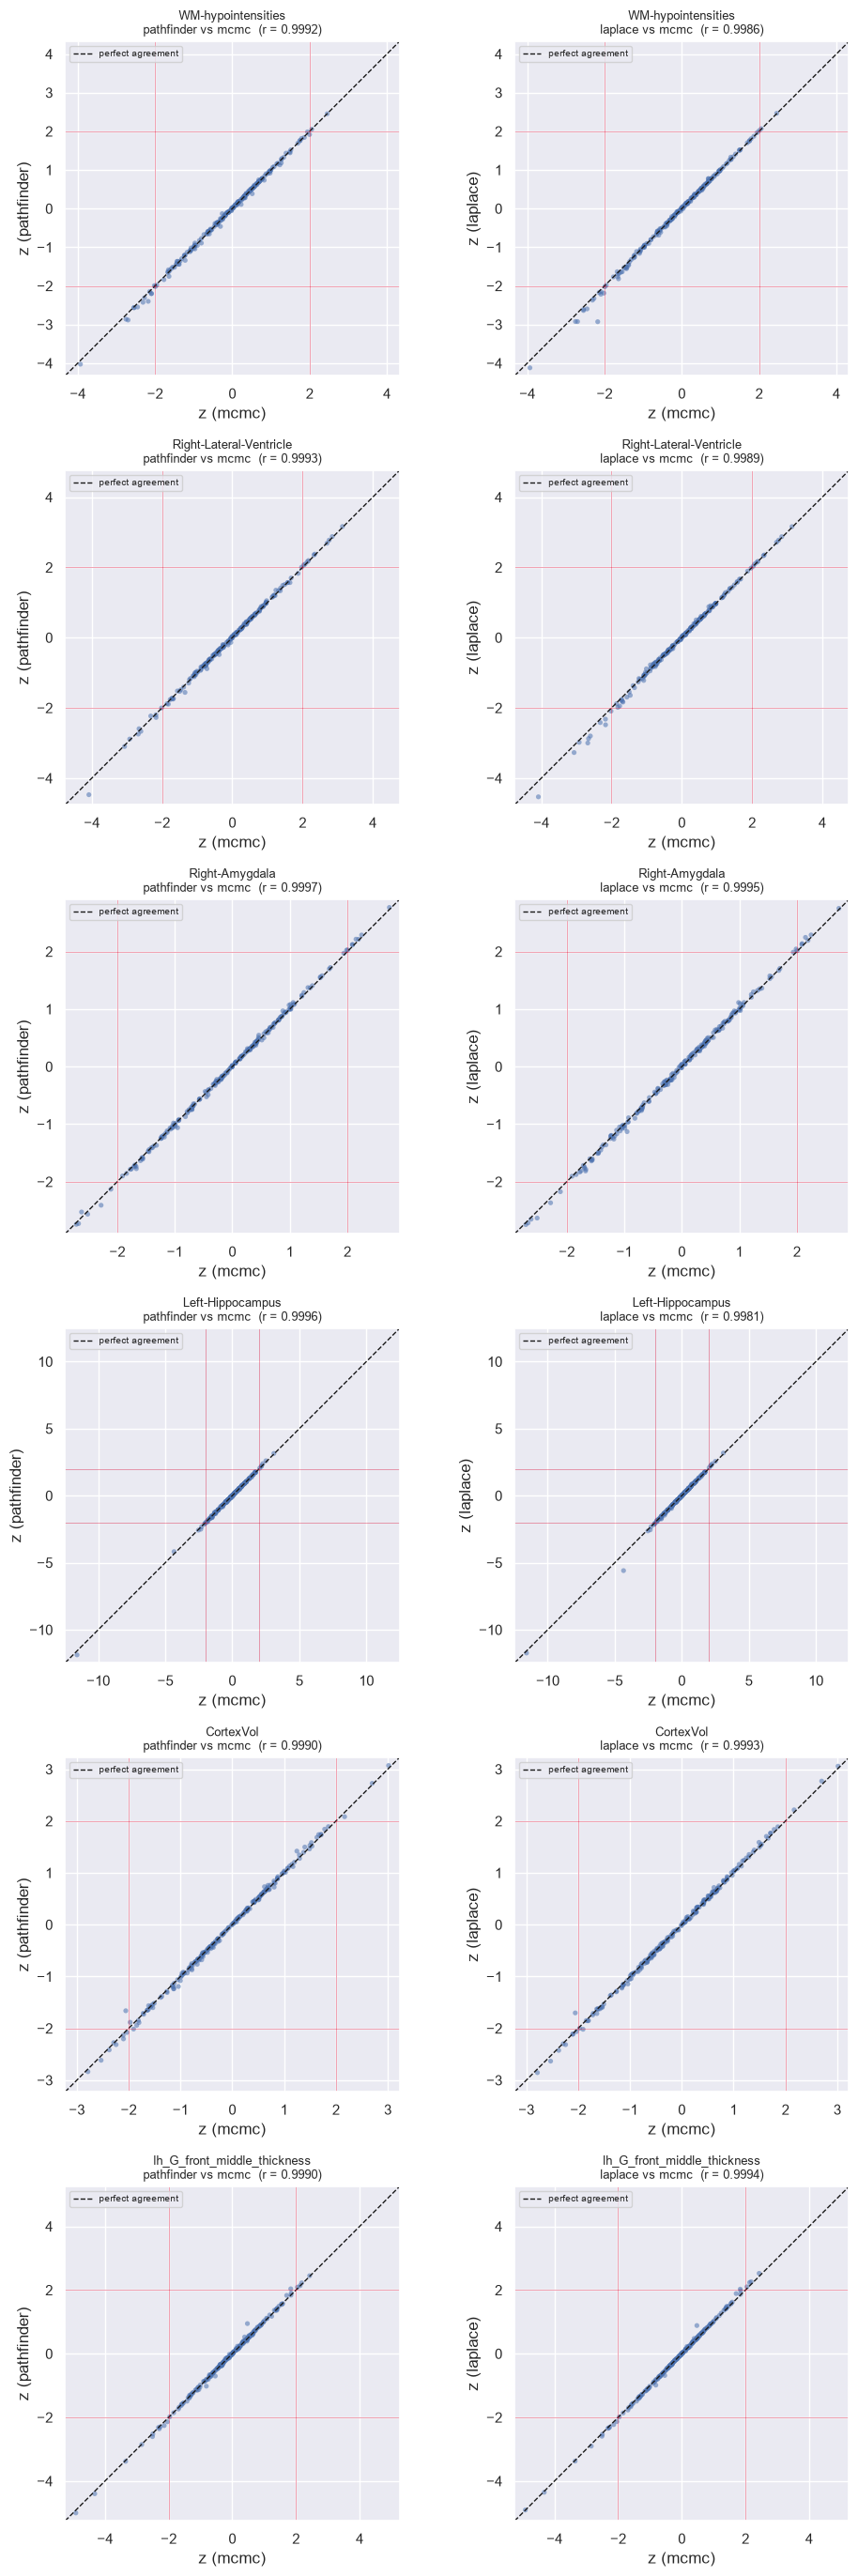

In [8]:
import matplotlib.pyplot as plt

# One row per response variable, one column per approximation.
fig, axes = plt.subplots(len(RESPONSE_VARS), len(others),
                         figsize=(5 * len(others), 4.6 * len(RESPONSE_VARS)),
                         squeeze=False)

for r, rv in enumerate(RESPONSE_VARS):
    zref_rv = zs[("mcmc", rv)]
    lim = float(np.abs(np.concatenate([zs[(m, rv)] for m in fits])).max()) * 1.05
    for c, method in enumerate(others):
        ax = axes[r][c]
        z = zs[(method, rv)]
        ax.scatter(zref_rv, z, s=14, alpha=0.55, edgecolor="none")
        ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="perfect agreement")
        # z = +-2 is the conventional outlier threshold.
        for t in (-2, 2):
            ax.axhline(t, color="crimson", lw=0.7, alpha=0.4)
            ax.axvline(t, color="crimson", lw=0.7, alpha=0.4)
        corr = np.corrcoef(z, zref_rv)[0, 1]
        ax.set_title(f"{rv}\n{method} vs mcmc  (r = {corr:.4f})", fontsize=9)
        ax.set_xlabel("z (mcmc)")
        ax.set_ylabel(f"z ({method})")
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal")
        ax.legend(loc="upper left", fontsize=7)

plt.tight_layout()
plt.show()

### Outliers detection

Subjects that cross the z = ±2 line between methods are the practical
cost of the approximation: same person, different outlier call.

In [9]:
THRESH = 2.0
rows = []
for rv in RESPONSE_VARS:
    zref_rv = zs[("mcmc", rv)]
    ref_out = np.abs(zref_rv) > THRESH
    for method in others:
        new_out = np.abs(zs[(method, rv)]) > THRESH
        rows.append({
            "response_var": rv,
            "method": method,
            f"outliers mcmc (|z|>{THRESH})": int(ref_out.sum()),
            "outliers approx": int(new_out.sum()),
            "disagreements": int((ref_out != new_out).sum()),
            "% of subjects": round(100 * float((ref_out != new_out).mean()), 2),
        })

out_df = pd.DataFrame(rows)
print("mean over response variables:")
print(out_df.groupby("method")[["disagreements", "% of subjects"]].mean().round(2))
out_df

mean over response variables:
            disagreements  % of subjects
method                                  
laplace              1.17           0.54
pathfinder           1.17           0.54


,response_var,method,outliers mcmc (|z|>2.0),outliers approx,disagreements,% of subjects
0,WM-hypointensities,pathfinder,15,15,2,0.93
1,WM-hypointensities,laplace,15,17,2,0.93
2,Right-Lateral-Ventricle,pathfinder,20,21,1,0.46
3,Right-Lateral-Ventricle,laplace,20,20,0,0.00
4,Right-Amygdala,pathfinder,13,14,1,0.46
5,Right-Amygdala,laplace,13,14,1,0.46
6,Left-Hippocampus,pathfinder,13,13,0,0.00
7,Left-Hippocampus,laplace,13,14,1,0.46
8,CortexVol,pathfinder,12,12,2,0.93
9,CortexVol,laplace,12,12,2,0.93


Conclusion: Pathfinder performs better than advi. It has less outliers and more similar z scores to the MCMC

## 2. Centiles vs MCMC

### Metrics

Differences are shown in Y units and as a percentage of the response
variable's standard deviation. 

To make the comparison precise and free of extrapolation we select the "inner" 95% of subjects and exclude the 5% of the subjects that lie on the sparse tails.

In [10]:
from pcntoolkit import NormData

ref_model = fits["mcmc"]
covariate = str(ref_model.covariates[0])
cov_min = ref_model.covariate_ranges[covariate]["min"]
cov_max = ref_model.covariate_ranges[covariate]["max"]
# Cast to plain str: batch effect keys come back as np.str_, which does not
# always compare equal to the column names downstream.
fixed_be = {
    str(k): str(max(v.items(), key=lambda x: x[1])[0])
    for k, v in ref_model.batch_effect_counts.items()
}
print(f"covariate: {covariate}   fixed batch effects: {fixed_be}")

grid_x = np.linspace(cov_min, cov_max, 150)
grid_df = pd.DataFrame({covariate: grid_x})
for cov in ref_model.covariates:
    if str(cov) != covariate:
        grid_df[str(cov)] = float(test.X.sel(covariates=cov).mean().values)
for be, v in fixed_be.items():
    grid_df[be] = v
for rv in ref_model.response_vars:
    grid_df[str(rv)] = 1e-6


def make_grid() -> NormData:
    """Fresh grid NormData (compute_centiles mutates its argument in place)."""
    return NormData.from_dataframe(
        "centile_grid",
        dataframe=grid_df.copy(),
        covariates=[str(c) for c in ref_model.covariates],
        response_vars=[str(r) for r in ref_model.response_vars],
        batch_effects=list(fixed_be.keys()),
    )


# centiles come back as (centile, grid point, response_var)
cents: dict[str, np.ndarray] = {}
grid_rvs: list[str] = []
for method, m in fits.items():
    gd = make_grid()
    m.compute_centiles(gd, centiles=CENTILES)
    cents[method] = np.asarray(gd["centiles"].values)
    grid_rvs = [str(r) for r in gd["centiles"].coords["response_vars"].values]

# Y sd per response variable, so centile errors are comparable across scales.
y_sds = {rv: float(np.nanstd(np.asarray(test.Y.sel(response_vars=rv).values).ravel()))
         for rv in RESPONSE_VARS}
cref = cents["mcmc"]

# To avoid extrapolation select the "inner" 95% of subjects and exclude
# the 5% of the subjects that lie on the sparse tails.
age_obs = np.asarray(test.X.values)[:, 0]
lo, hi = np.percentile(age_obs, [2.5, 97.5])
inner = (grid_x >= lo) & (grid_x <= hi)
print(f"comparing over {covariate} in [{lo:.1f}, {hi:.1f}] "
      f"({inner.sum()}/{len(grid_x)} grid points)")

rows = []
for method, c in cents.items():
    if method == "mcmc" or c.shape != cref.shape:
        continue
    for j, rv in enumerate(grid_rvs):
        y_sd_rv = y_sds[rv]
        d = np.abs(c[:, :, j] - cref[:, :, j])
        d_in = d[:, inner]
        imax = np.unravel_index(np.argmax(d_in), d_in.shape)
        rows.append({
            "response_var": rv,
            "method": method,
            "max % Y sd (all)": round(100 * float(d.max()) / y_sd_rv, 1),
            "max % Y sd (inner)": round(100 * float(d_in.max()) / y_sd_rv, 1),
            "mean % Y sd (inner)": round(100 * float(d_in.mean()) / y_sd_rv, 1),
            "median % Y sd (inner)": round(100 * float(np.median(d_in)) / y_sd_rv, 1),
            "worst centile": CENTILES[imax[0]],
            f"worst {covariate}": round(float(grid_x[inner][imax[1]]), 1),
        })

cent_df = pd.DataFrame(rows)
print("\nmean over response variables:")
print(cent_df.groupby("method")[["max % Y sd (inner)", "mean % Y sd (inner)"]].mean().round(1))
cent_df

covariate: age   fixed batch effects: {'sex': 'F', 'site': 'Beijing_Zang'}
comparing over age in [18.0, 66.6] (94/150 grid points)

mean over response variables:
            max % Y sd (inner)  mean % Y sd (inner)
method                                             
laplace                   13.5                  2.4
pathfinder                19.8                  3.3


,response_var,method,max % Y sd (all),max % Y sd (inner),mean % Y sd (inner),median % Y sd (inner),worst centile,worst age
0,WM-hypointensities,pathfinder,647.7,42.4,5.0,1.8,0.95,61.7
1,Right-Lateral-Ventricle,pathfinder,44.7,37.6,4.1,1.5,0.95,66.4
2,Right-Amygdala,pathfinder,43.6,5.4,1.5,1.3,0.95,66.4
3,Left-Hippocampus,pathfinder,46.0,11.9,4.1,3.8,0.05,62.2
4,CortexVol,pathfinder,47.5,15.1,2.6,1.9,0.95,66.4
5,lh_G_front_middle_thickness,pathfinder,90.5,6.7,2.5,2.3,0.95,66.4
6,WM-hypointensities,laplace,97.3,30.4,3.2,2.0,0.95,66.4
7,Right-Lateral-Ventricle,laplace,97.4,18.3,2.1,1.7,0.95,66.4
8,Right-Amygdala,laplace,50.1,7.0,2.2,1.9,0.05,66.4
9,Left-Hippocampus,laplace,23.5,9.0,2.0,1.6,0.05,66.4


### Plot 
Plot the centile curves against age. Solid = MCMC, dashed = the
approximation.

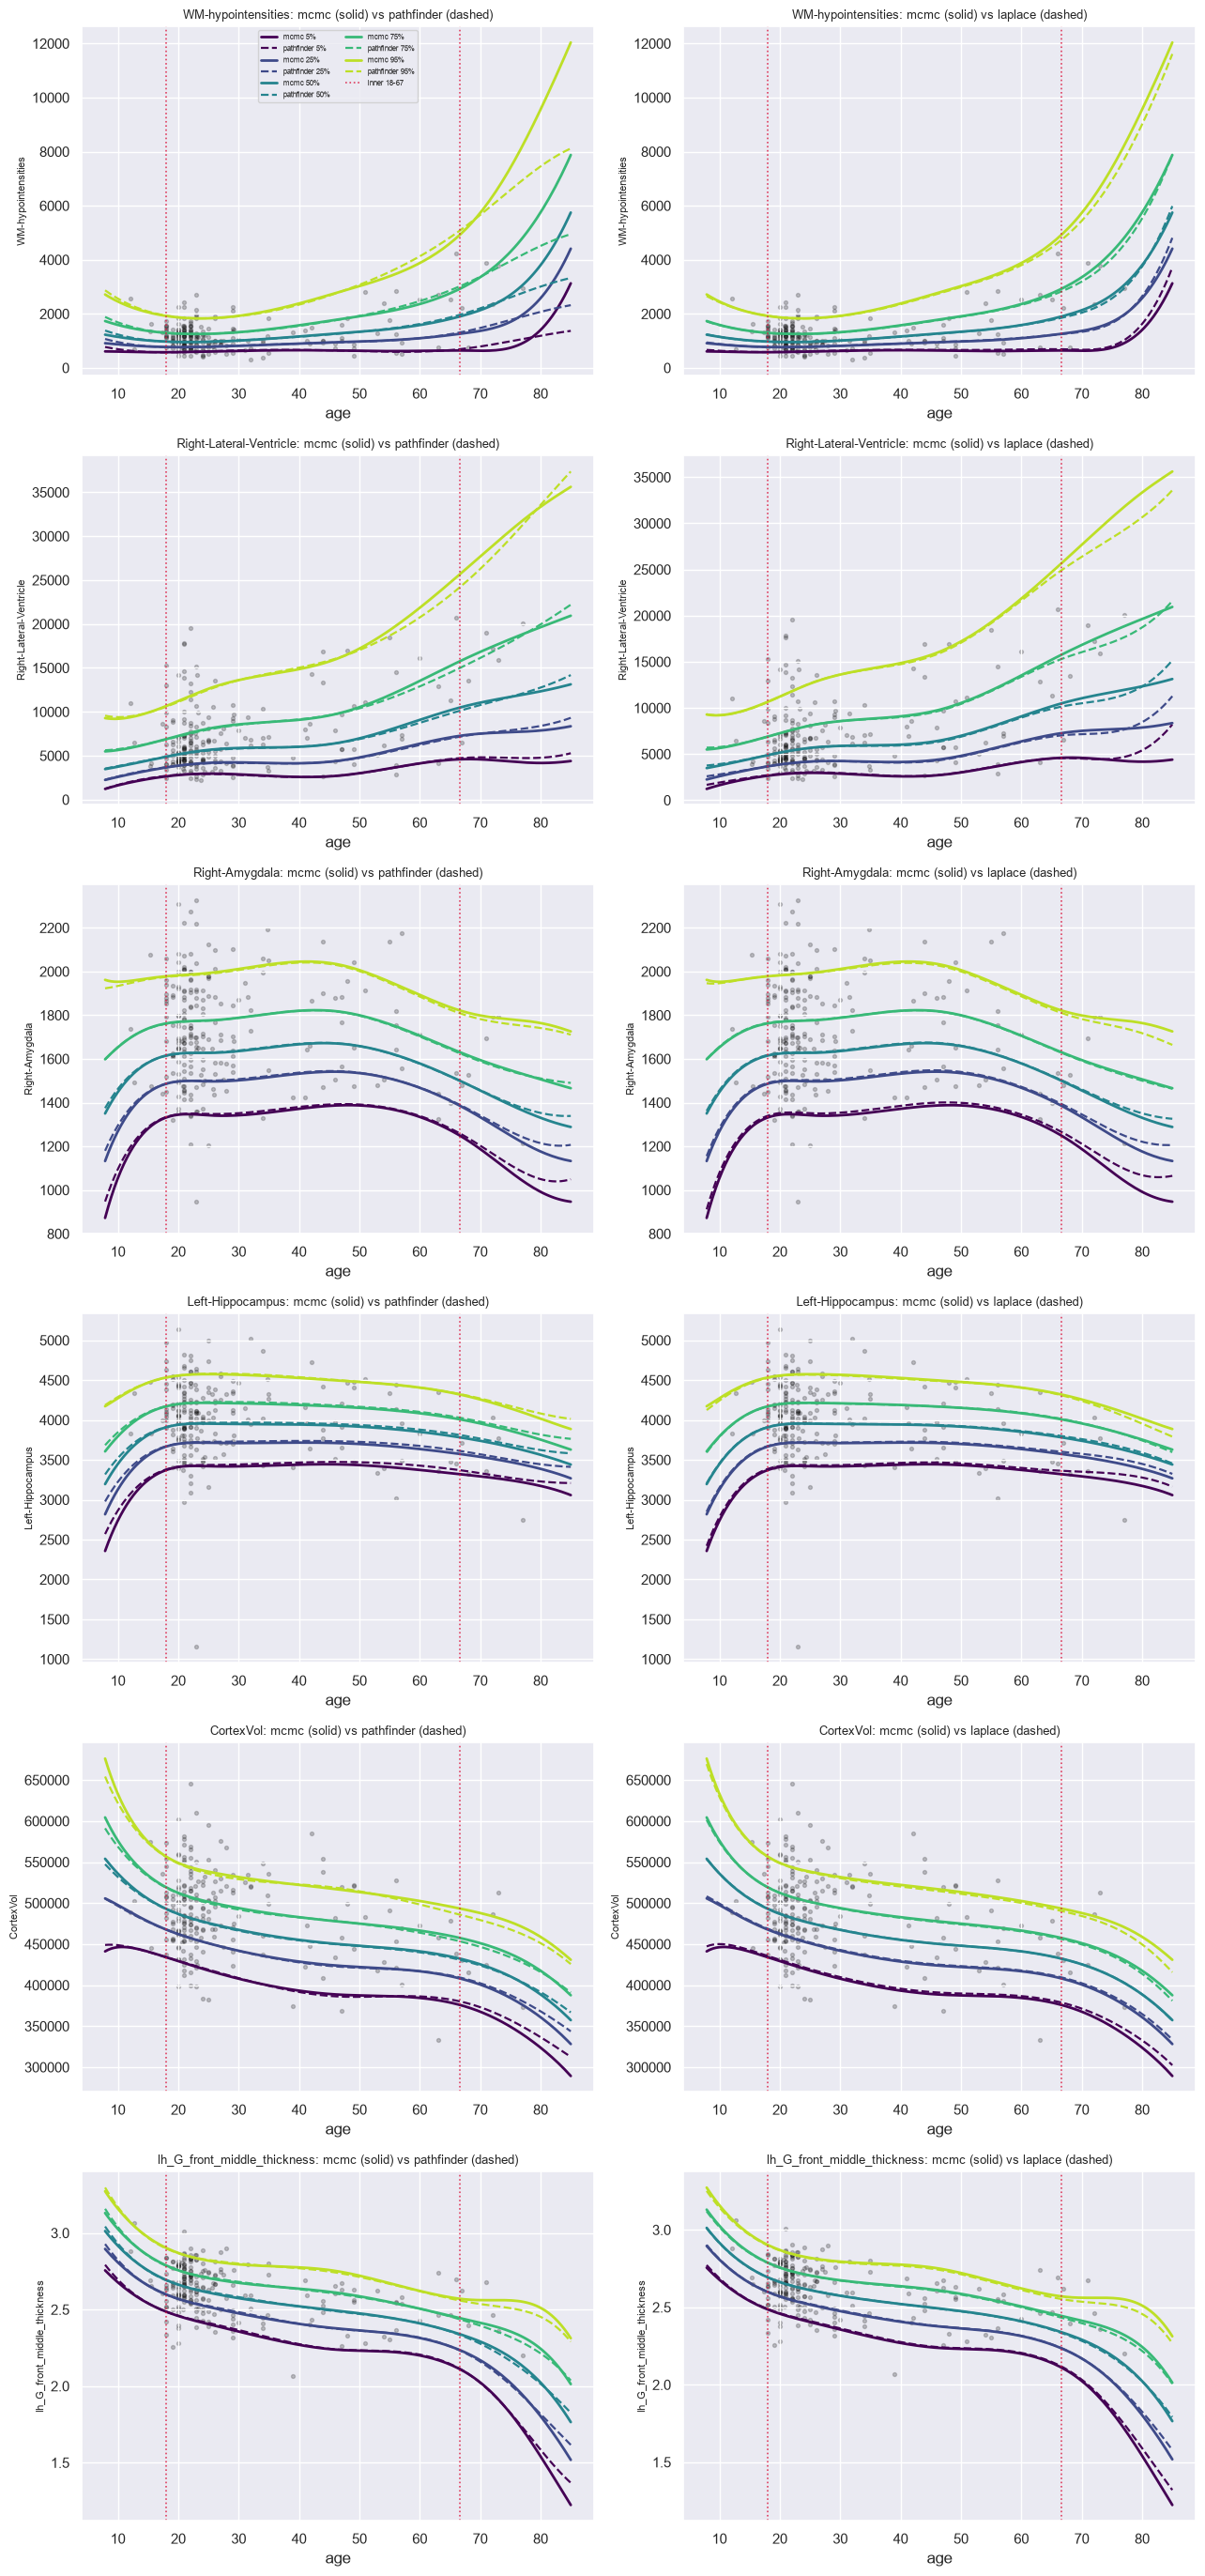

In [11]:
# Overlay for a direct visual diff: MCMC solid, approximation dashed.
# One row per response variable, one column per approximation.
fig, axes = plt.subplots(len(grid_rvs), len(others),
                         figsize=(6.5 * len(others), 4.6 * len(grid_rvs)),
                         squeeze=False)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(CENTILES)))

for r, rv in enumerate(grid_rvs):
    for c, method in enumerate(others):
        ax = axes[r][c]
        for i, cent in enumerate(CENTILES):
            ax.plot(grid_x, cref[i, :, r], color=colors[i], lw=2,
                    label=f"mcmc {int(cent * 100)}%")
            ax.plot(grid_x, cents[method][i, :, r], color=colors[i], lw=1.6,
                    ls="--", label=f"{method} {int(cent * 100)}%")
        ax.scatter(np.asarray(test.X.values)[:, 0],
                   np.asarray(test.Y.sel(response_vars=rv).values).ravel(),
                   s=8, color="black", alpha=0.2, zorder=0)

        # `lo` and `hi` are the inner 95% of test ages from the cell above;
        # reusing them keeps the plot and the numeric tables in sync.
        ax.axvline(lo, color="crimson", ls=":", lw=1.2, alpha=0.8,
                   label=f"inner {lo:.0f}-{hi:.0f}")
        ax.axvline(hi, color="crimson", ls=":", lw=1.2, alpha=0.8)

        ax.set_title(f"{rv}: mcmc (solid) vs {method} (dashed)", fontsize=9)
        ax.set_xlabel(covariate)
        ax.set_ylabel(rv, fontsize=8)
        if r == 0 and c == 0:
            ax.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.show()

Train ages span [7.9, 85.0], so the plot above covers all training data. But the "inner" 95% of subjects fall in [18.0, 66.6] —> only 5% lie in the sparse tails below 18 or above 67 -> this leads to either MCMC or the VIs being not precise there -> that is where they disagree.

Conclusions: 

Pathfinder should a good agreement inside the [18.0, 66.6] (some divergence is seen though for the 0.95 centile for older ages. 

ADVI performs worse than Pathfilder as it disagrees with MCMC also inside the [18.0, 66.6]. 

## 3. Posterior width vs MCMC

`sd_ratio` = approximate sd / MCMC sd, per parameter.

- **1.0** matches MCMC
- **< 1** underestimates uncertainty - the dangerous direction, since it
  inflates z-scores and invents outliers
- `mean_shift` is the gap between posterior means, in MCMC standard
  deviations. Above ~1 the parameter estimate itself is off, not just its
  uncertainty.

In [12]:
# One regression model per response variable, so sd_ratio is computed per model.
rows = []
for rv in RESPONSE_VARS:
    ref_idata = fits["mcmc"][rv].idata
    param_names = [v for v in ref_idata.posterior.data_vars if "_per_subject" not in v]
    for method in others:
        idata = fits[method][rv].idata
        for v in sorted(param_names):
            if v not in idata.posterior:
                continue
            a = idata.posterior[v].values
            b = ref_idata.posterior[v].values
            if a.size == 0 or b.size == 0 or b.std() == 0:
                continue
            rows.append({
                "response_var": rv,
                "method": method,
                "parameter": v,
                "sd_ratio": round(float(a.std() / b.std()), 3),
                "mean_shift (sd)": round(float(abs(a.mean() - b.mean()) / b.std()), 2),
            })

width_df = pd.DataFrame(rows)

# Averaged over response variables: which parameters does each method collapse?
summary = (width_df.groupby(["method", "parameter"])[["sd_ratio", "mean_shift (sd)"]]
           .mean().round(3).reset_index()
           .sort_values(["method", "sd_ratio"]))
print("mean sd_ratio over response variables (1.0 = matches MCMC):")
print(summary.to_string(index=False))
width_df.sort_values(["response_var", "method", "sd_ratio"]).reset_index(drop=True)

mean sd_ratio over response variables (1.0 = matches MCMC):
    method                           parameter  sd_ratio  mean_shift (sd)
   laplace normalized_site_offset_intercept_mu     0.344            0.000
   laplace                            slope_mu     0.413            0.023
   laplace                               delta     0.709            0.188
   laplace  normalized_sex_offset_intercept_mu     0.860            0.000
   laplace              sex_sigma_intercept_mu     0.864            0.218
   laplace                     intercept_sigma     0.894            0.158
   laplace                         slope_sigma     0.904            0.030
   laplace                     mu_intercept_mu     0.922            0.067
   laplace             sex_offset_intercept_mu     0.940            0.000
   laplace                             epsilon     1.031            0.333
   laplace            site_offset_intercept_mu     1.071            0.000
   laplace             site_sigma_intercept_mu     1

,response_var,method,parameter,sd_ratio,mean_shift (sd)
0,CortexVol,laplace,slope_mu,0.326,0.02
1,CortexVol,laplace,normalized_site_offset_intercept_mu,0.375,0.00
2,CortexVol,laplace,delta,0.686,0.14
3,CortexVol,laplace,sex_sigma_intercept_mu,0.880,0.23
4,CortexVol,laplace,slope_sigma,0.896,0.03
...,...,...,...,...,...
139,lh_G_front_middle_thickness,pathfinder,slope_sigma,0.725,0.16
140,lh_G_front_middle_thickness,pathfinder,normalized_sex_offset_intercept_mu,0.845,0.00
141,lh_G_front_middle_thickness,pathfinder,sex_offset_intercept_mu,0.967,0.00
142,lh_G_front_middle_thickness,pathfinder,epsilon,0.992,0.10
